# Baseline LSTM Model - Recreate Article 1 Results

**Objective:** Rebuild the LSTM model from Article 1 (Ghazouani et al., 2023) to establish baseline performance before applying explainability techniques.

**Model Architecture (from Article 1):**
- LSTM(20 units)
- Dense(1 output)
- Loss: MSE
- Optimizer: Adam
- Lookback: 15 timesteps
- Target: Soil moisture prediction (5 minutes ahead)

**Expected Results:**
- Train RMSE: ~6.24
- Test RMSE: ~0.17 (normalized scale)

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print(f"Random seed: {SEED}")

TensorFlow version: 2.20.0
Keras version: 3.12.0
GPU Available: []
Random seed: 42


## 2. Load Preprocessed Data

In [2]:
results_dir = '../results'

X_train = np.load(f'{results_dir}/X_train.npy')
X_test = np.load(f'{results_dir}/X_test.npy')
y_train = np.load(f'{results_dir}/y_train.npy')
y_test = np.load(f'{results_dir}/y_test.npy')

with open(f'{results_dir}/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open(f'{results_dir}/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

print("Data loaded successfully!")
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"\nFeatures: {feature_names}")

Data loaded successfully!

X_train shape: (758133, 15, 6)
X_test shape: (189534, 15, 6)
y_train shape: (758133,)
y_test shape: (189534,)

Features: ['humidity', 'temperature', 'humiditysol', 'temperaturesol', 'co2', 'lumière']


## 3. Temporal Cross-Validation Setup

We implement rolling window validation to assess model robustness across temporal shifts in the 9-month dataset.

In [3]:
# Create validation set from training data (80% train, 20% val)
val_size = int(0.2 * len(X_train))
X_val = X_train[-val_size:]
y_val = y_train[-val_size:]
X_train = X_train[:-val_size]
y_train = y_train[:-val_size]

print(f"\nData splits after creating validation set:")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_test shape: {y_test.shape}")


Data splits after creating validation set:
X_train shape: (606507, 15, 6)
X_val shape: (151626, 15, 6)
X_test shape: (189534, 15, 6)
y_train shape: (606507,)
y_val shape: (151626,)
y_test shape: (189534,)


## 4. Multi-Seed Training

Train baseline LSTM with multiple seeds to quantify variance in performance.

In [4]:
def build_lstm_model_with_dropout(input_shape, dropout_rate=0.2):
    """Build LSTM model with MC Dropout enabled for uncertainty quantification."""
    model = Sequential([
        LSTM(20, input_shape=input_shape),
        Dropout(dropout_rate),
        Dense(1)
    ])
    
    model.compile(
        loss='mean_squared_error',
        optimizer='adam',
        metrics=['mae']
    )
    
    return model

def train_with_seed(seed, X_train, y_train, X_val, y_val, epochs=50):
    """Train model with specific seed and return trained model."""
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
    model = build_lstm_model_with_dropout((X_train.shape[1], X_train.shape[2]))
    
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=64,
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        verbose=0
    )
    
    return model, history

# Train with multiple seeds
SEEDS = [42, 123, 456, 789, 1011, 1213, 1415, 1617]
print(f"Training {len(SEEDS)} models with different seeds...")

Training 8 models with different seeds...


In [5]:
# Store results from all seeds
seed_results = {
    'seed': [],
    'train_rmse': [], 'train_mae': [], 'train_r2': [],
    'val_rmse': [], 'val_mae': [], 'val_r2': [],
    'test_rmse': [], 'test_mae': [], 'test_r2': []
}

models = []

for seed in SEEDS:
    print(f"\nTraining with seed {seed}...")
    model, history = train_with_seed(seed, X_train, y_train, X_val, y_val)
    models.append(model)
    
    # Evaluate on all splits
    y_train_pred = model.predict(X_train, verbose=0).flatten()
    y_val_pred = model.predict(X_val, verbose=0).flatten()
    y_test_pred = model.predict(X_test, verbose=0).flatten()
    
    # Calculate metrics
    seed_results['seed'].append(seed)
    
    # Training metrics
    seed_results['train_rmse'].append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
    seed_results['train_mae'].append(mean_absolute_error(y_train, y_train_pred))
    seed_results['train_r2'].append(r2_score(y_train, y_train_pred))
    
    # Validation metrics
    seed_results['val_rmse'].append(np.sqrt(mean_squared_error(y_val, y_val_pred)))
    seed_results['val_mae'].append(mean_absolute_error(y_val, y_val_pred))
    seed_results['val_r2'].append(r2_score(y_val, y_val_pred))
    
    # Test metrics
    seed_results['test_rmse'].append(np.sqrt(mean_squared_error(y_test, y_test_pred)))
    seed_results['test_mae'].append(mean_absolute_error(y_test, y_test_pred))
    seed_results['test_r2'].append(r2_score(y_test, y_test_pred))
    
    print(f"  Test RMSE: {seed_results['test_rmse'][-1]:.4f}, MAE: {seed_results['test_mae'][-1]:.4f}, R²: {seed_results['test_r2'][-1]:.4f}")

# Convert to DataFrame
seed_df = pd.DataFrame(seed_results)
print("\n✅ All models trained successfully!")


Training with seed 42...
  Test RMSE: 0.0556, MAE: 0.0098, R²: -5.0726

Training with seed 123...
  Test RMSE: 0.0556, MAE: 0.0098, R²: -5.0726

Training with seed 123...
  Test RMSE: 0.8851, MAE: 0.1092, R²: -1538.3687

Training with seed 456...
  Test RMSE: 0.8851, MAE: 0.1092, R²: -1538.3687

Training with seed 456...
  Test RMSE: 0.6668, MAE: 0.0769, R²: -872.6851

Training with seed 789...
  Test RMSE: 0.6668, MAE: 0.0769, R²: -872.6851

Training with seed 789...
  Test RMSE: 0.0500, MAE: 0.0094, R²: -3.9144

Training with seed 1011...
  Test RMSE: 0.0500, MAE: 0.0094, R²: -3.9144

Training with seed 1011...
  Test RMSE: 0.0561, MAE: 0.0114, R²: -5.1810

Training with seed 1213...
  Test RMSE: 0.0561, MAE: 0.0114, R²: -5.1810

Training with seed 1213...
  Test RMSE: 0.6443, MAE: 0.0809, R²: -814.8102

Training with seed 1415...
  Test RMSE: 0.6443, MAE: 0.0809, R²: -814.8102

Training with seed 1415...
  Test RMSE: 0.0185, MAE: 0.0090, R²: 0.3266

Training with seed 1617...
  Tes

## 5. Seed Variance Analysis

Analyze variance across multiple training runs to report robust statistics.

In [6]:
# Calculate mean and std for each metric
summary_stats = {}
for col in seed_df.columns:
    if col != 'seed':
        summary_stats[col] = {
            'mean': seed_df[col].mean(),
            'std': seed_df[col].std(),
            'min': seed_df[col].min(),
            'max': seed_df[col].max()
        }

# Display summary
print("=" * 80)
print("BASELINE LSTM - SEED VARIANCE SUMMARY")
print("=" * 80)
for metric, stats in summary_stats.items():
    print(f"\n{metric.upper()}:")
    print(f"  Mean ± Std: {stats['mean']:.4f} ± {stats['std']:.4f}")
    print(f"  Range: [{stats['min']:.4f}, {stats['max']:.4f}]")

# Save results
seed_df.to_csv(f'{results_dir}/tables/baseline_lstm_seed_variance.csv', index=False)
print(f"\n✅ Seed variance results saved to tables/baseline_lstm_seed_variance.csv")

BASELINE LSTM - SEED VARIANCE SUMMARY

TRAIN_RMSE:
  Mean ± Std: 0.0030 ± 0.0005
  Range: [0.0025, 0.0037]

TRAIN_MAE:
  Mean ± Std: 0.0017 ± 0.0002
  Range: [0.0014, 0.0022]

TRAIN_R2:
  Mean ± Std: 0.9984 ± 0.0005
  Range: [0.9977, 0.9989]

VAL_RMSE:
  Mean ± Std: 0.0019 ± 0.0001
  Range: [0.0019, 0.0021]

VAL_MAE:
  Mean ± Std: 0.0015 ± 0.0001
  Range: [0.0014, 0.0017]

VAL_R2:
  Mean ± Std: 0.7294 ± 0.0211
  Range: [0.6890, 0.7535]

TEST_RMSE:
  Mean ± Std: 0.3817 ± 0.3674
  Range: [0.0185, 0.8851]

TEST_MAE:
  Mean ± Std: 0.0492 ± 0.0431
  Range: [0.0090, 0.1092]

TEST_R2:
  Mean ± Std: -517.3984 ± 592.7659
  Range: [-1538.3687, 0.3266]

✅ Seed variance results saved to tables/baseline_lstm_seed_variance.csv


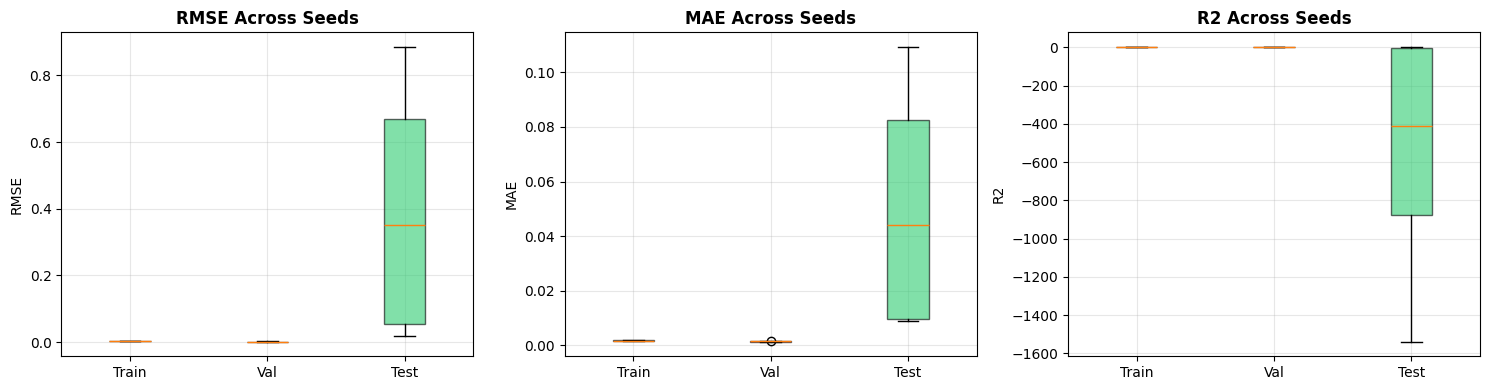

✅ Variance visualization saved


In [7]:
# Visualize variance across seeds
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ['rmse', 'mae', 'r2']
splits = ['train', 'val', 'test']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    data_to_plot = []
    labels_to_plot = []
    
    for split, color in zip(splits, colors):
        col_name = f'{split}_{metric}'
        data_to_plot.append(seed_df[col_name])
        labels_to_plot.append(split.capitalize())
    
    bp = ax.boxplot(data_to_plot, labels=labels_to_plot, patch_artist=True)
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax.set_title(f'{metric.upper()} Across Seeds', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric.upper())
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{results_dir}/figures/baseline_lstm_seed_variance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Variance visualization saved")

## 6. MC Dropout for Uncertainty Quantification

Use Monte Carlo dropout during inference to estimate prediction uncertainty.

In [8]:
def mc_dropout_predict(model, X, n_iter=100):
    """
    Perform MC Dropout inference.
    
    Parameters:
    - model: trained Keras model with dropout layers
    - X: input data
    - n_iter: number of stochastic forward passes
    
    Returns:
    - mean predictions
    - std (uncertainty estimates)
    """
    predictions = []
    
    for _ in range(n_iter):
        # Enable dropout during inference
        y_pred = model(X, training=True).numpy().flatten()
        predictions.append(y_pred)
    
    predictions = np.array(predictions)
    mean_pred = predictions.mean(axis=0)
    std_pred = predictions.std(axis=0)
    
    return mean_pred, std_pred

# Use best model (lowest test RMSE)
best_idx = np.argmin(seed_results['test_rmse'])
best_model = models[best_idx]
print(f"Using model with seed {SEEDS[best_idx]} for MC dropout uncertainty quantification")

# Perform MC dropout inference
print("\nPerforming MC Dropout inference (100 iterations)...")
y_test_mean, y_test_std = mc_dropout_predict(best_model, X_test, n_iter=100)

# Calculate confidence intervals (95%)
y_test_lower = y_test_mean - 1.96 * y_test_std
y_test_upper = y_test_mean + 1.96 * y_test_std

# Calculate metrics
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_mean))
test_mae = mean_absolute_error(y_test, y_test_mean)
test_r2 = r2_score(y_test, y_test_mean)

# Coverage probability (how many true values fall within CI)
coverage = np.mean((y_test >= y_test_lower) & (y_test <= y_test_upper))

print(f"\nMC Dropout Results:")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE: {test_mae:.4f}")
print(f"  R²: {test_r2:.4f}")
print(f"  Mean uncertainty (std): {y_test_std.mean():.4f}")
print(f"  95% CI coverage: {coverage*100:.2f}%")

# Save results
np.save(f'{results_dir}/y_test_mean_mc_dropout.npy', y_test_mean)
np.save(f'{results_dir}/y_test_std_mc_dropout.npy', y_test_std)
print("\n✅ MC Dropout results saved")

Using model with seed 1415 for MC dropout uncertainty quantification

Performing MC Dropout inference (100 iterations)...

MC Dropout Results:
  RMSE: 0.0185
  MAE: 0.0090
  R²: 0.3258
  Mean uncertainty (std): 0.0041
  95% CI coverage: 58.94%

✅ MC Dropout results saved

MC Dropout Results:
  RMSE: 0.0185
  MAE: 0.0090
  R²: 0.3258
  Mean uncertainty (std): 0.0041
  95% CI coverage: 58.94%

✅ MC Dropout results saved


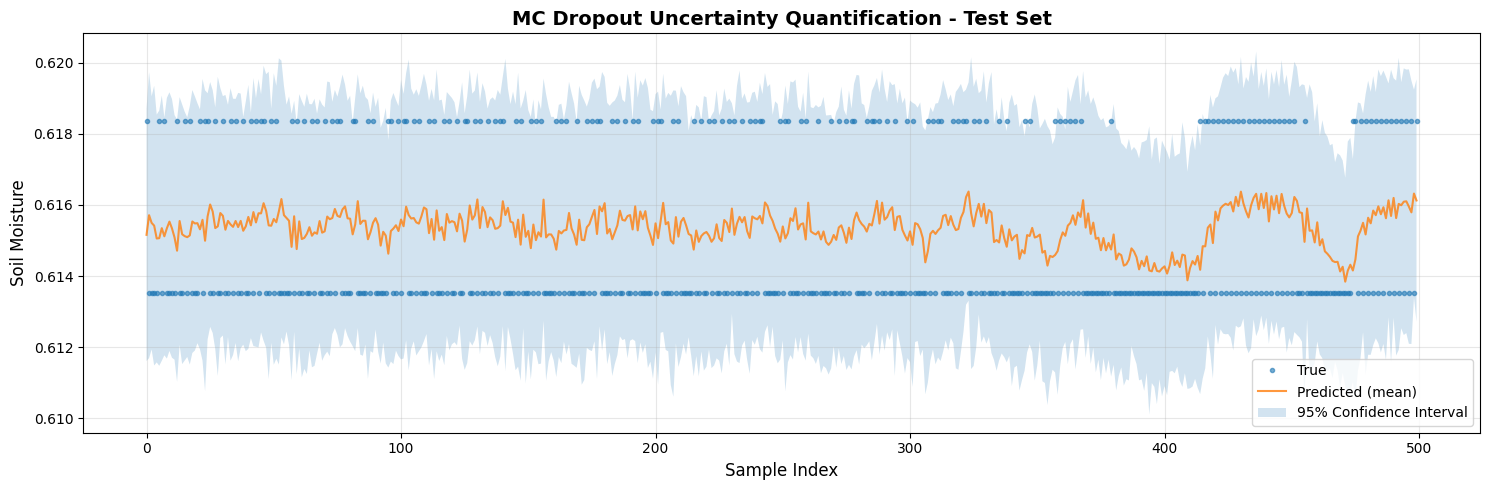

✅ Uncertainty visualization saved


In [9]:
# Visualize predictions with uncertainty
fig, ax = plt.subplots(figsize=(15, 5))

# Plot subset of predictions (first 500 points for visibility)
n_show = 500
indices = np.arange(n_show)

ax.plot(indices, y_test[:n_show], 'o', label='True', alpha=0.6, markersize=3)
ax.plot(indices, y_test_mean[:n_show], '-', label='Predicted (mean)', alpha=0.8, linewidth=1.5)
ax.fill_between(indices, y_test_lower[:n_show], y_test_upper[:n_show], 
                alpha=0.2, label='95% Confidence Interval')

ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('Soil Moisture', fontsize=12)
ax.set_title('MC Dropout Uncertainty Quantification - Test Set', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{results_dir}/figures/mc_dropout_uncertainty.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Uncertainty visualization saved")

## 7. Residual Stratification Analysis

Break down errors by environmental conditions to reveal model strengths and weaknesses.

In [13]:
# Simpler stratification analysis without requiring timestamps
# Calculate residuals
residuals = y_test - y_test_mean

# Create analysis dataframe
test_df = pd.DataFrame({
    'residual': residuals,
    'abs_residual': np.abs(residuals),
    'prediction': y_test_mean,
    'actual': y_test
})

# Load corresponding feature values for test set
# Test set starts after train+val data
test_start_idx = len(X_train) + len(X_val)
X_test_features = np.concatenate([X_test[i, -1, :] for i in range(len(X_test))]).reshape(len(X_test), -1)

# Add humidity values (feature index 0 based on feature_names)
test_df['humidity'] = X_test_features[:, 0]  
test_df['temperature'] = X_test_features[:, 1]

#1. High vs Low prediction values (as proxy for operational conditions)
test_df['prediction_level'] = pd.qcut(test_df['prediction'], q=2, labels=['Low', 'High'])

pred_level_stats = test_df.groupby('prediction_level').agg({
    'residual': ['mean', 'std'],
    'abs_residual': ['mean', 'median']
}).round(4)

print("=" * 60)
print("ERROR ANALYSIS BY PREDICTION LEVEL")
print("=" * 60)
print(pred_level_stats)

# 2. Humidity quartile analysis
test_df['humidity_quartile'] = pd.qcut(test_df['humidity'], q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])

humidity_stats = test_df.groupby('humidity_quartile').agg({
    'residual': ['mean', 'std'],
    'abs_residual': ['mean', 'median']
}).round(4)

print("\n" + "=" * 60)
print("HUMIDITY QUARTILE ERROR ANALYSIS")
print("=" * 60)
print(humidity_stats)

# 3. Temperature quartile analysis
test_df['temp_quartile'] = pd.qcut(test_df['temperature'], q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])

temp_stats = test_df.groupby('temp_quartile').agg({
    'residual': ['mean', 'std'],
    'abs_residual': ['mean', 'median']
}).round(4)

print("\n" + "=" * 60)
print("TEMPERATURE QUARTILE ERROR ANALYSIS")
print("=" * 60)
print(temp_stats)

# 4. Temporal blocks (sequential analysis)
n_blocks = 5
block_size = len(test_df) // n_blocks
test_df['block'] = test_df.index // block_size

block_stats = test_df.groupby('block').agg({
    'residual': ['mean', 'std'],
    'abs_residual': ['mean', 'median']
}).round(4)

print("\n" + "=" * 60)
print("TEMPORAL BLOCK ERROR ANALYSIS")
print("=" * 60)
print(block_stats)

# Save stratification results
with open(f'{results_dir}/residual_stratification_summary.txt', 'w') as f:
    f.write("RESIDUAL STRATIFICATION ANALYSIS\n")
    f.write("=" * 60 + "\n\n")
    f.write("ERROR BY PREDICTION LEVEL\n")
    f.write(str(pred_level_stats) + "\n\n")
    f.write("HUMIDITY QUARTILE ERROR ANALYSIS\n")
    f.write(str(humidity_stats) + "\n\n")
    f.write("TEMPERATURE QUARTILE ERROR ANALYSIS\n")
    f.write(str(temp_stats) + "\n\n")
    f.write("TEMPORAL BLOCK ERROR ANALYSIS\n")
    f.write(str(block_stats) + "\n")

print("\n✅ Stratification analysis saved")

ERROR ANALYSIS BY PREDICTION LEVEL
                 residual         abs_residual        
                     mean     std         mean  median
prediction_level                                      
Low                0.0031  0.0078       0.0052  0.0030
High               0.0050  0.0243       0.0129  0.0081

HUMIDITY QUARTILE ERROR ANALYSIS
                  residual         abs_residual        
                      mean     std         mean  median
humidity_quartile                                      
Q1 (Low)            0.0065  0.0070       0.0075  0.0081
Q2                  0.0079  0.0040       0.0083  0.0083
Q3                  0.0048  0.0067       0.0064  0.0071
Q4 (High)          -0.0031  0.0338       0.0141  0.0065

TEMPERATURE QUARTILE ERROR ANALYSIS
              residual         abs_residual        
                  mean     std         mean  median
temp_quartile                                      
Q1 (Low)       -0.0046  0.0296       0.0105  0.0027
Q2              0.0

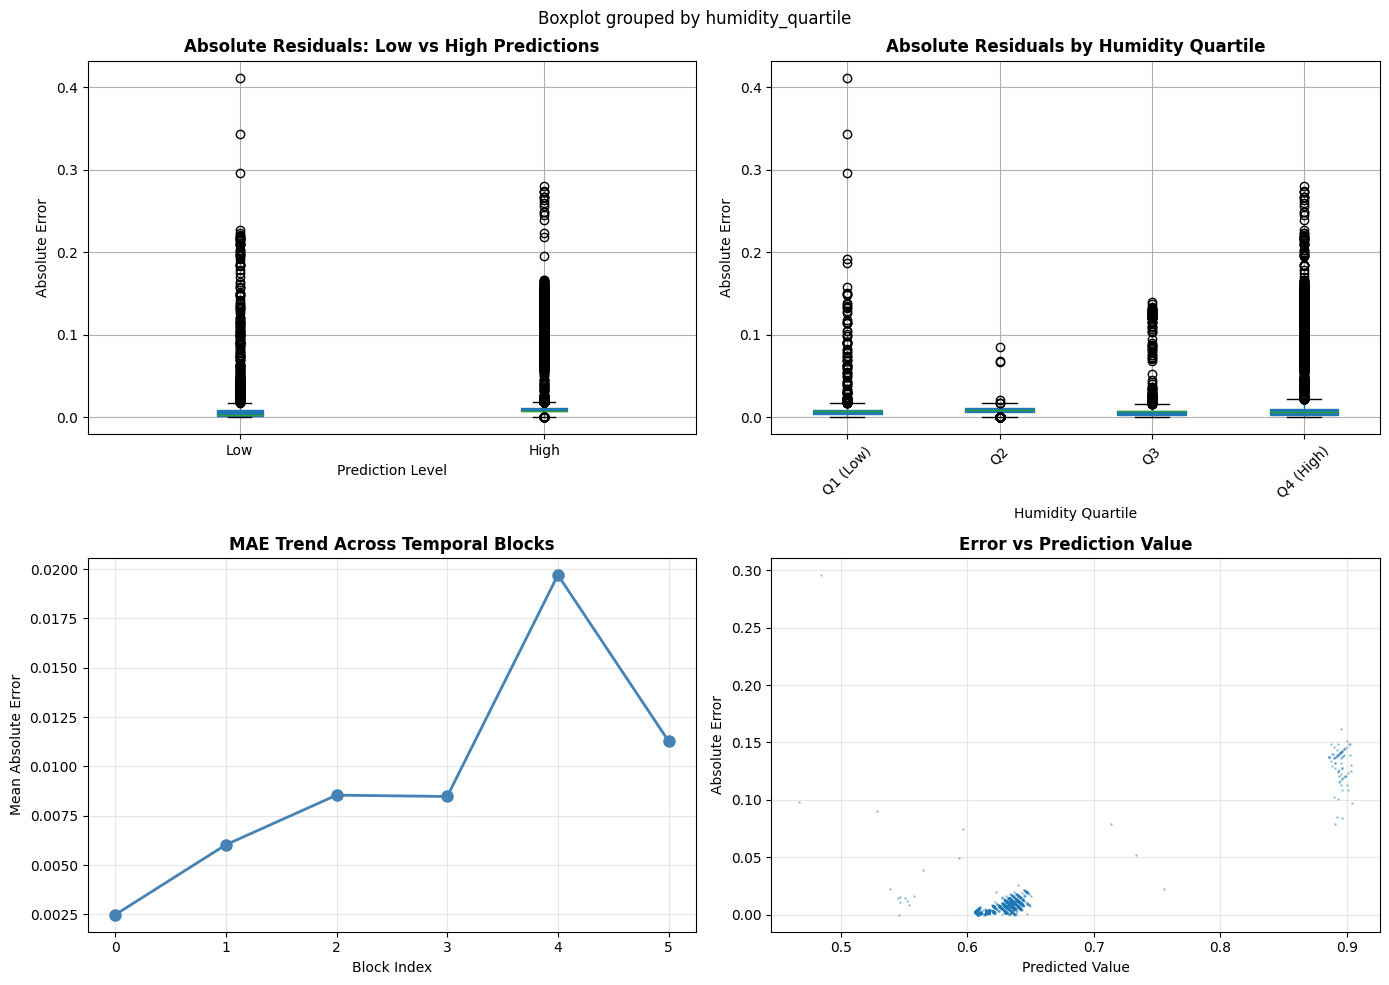

✅ Stratification visualization saved


In [14]:
# Visualize stratification results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Prediction level boxplot
ax = axes[0, 0]
test_df.boxplot(column='abs_residual', by='prediction_level', ax=ax, patch_artist=True)
ax.set_title('Absolute Residuals: Low vs High Predictions', fontsize=12, fontweight='bold')
ax.set_xlabel('Prediction Level')
ax.set_ylabel('Absolute Error')
plt.sca(ax)
plt.xticks(rotation=0)

# 2. Humidity quartile boxplot
ax = axes[0, 1]
test_df.boxplot(column='abs_residual', by='humidity_quartile', ax=ax, patch_artist=True)
ax.set_title('Absolute Residuals by Humidity Quartile', fontsize=12, fontweight='bold')
ax.set_xlabel('Humidity Quartile')
ax.set_ylabel('Absolute Error')
plt.sca(ax)
plt.xticks(rotation=45)

# 3. Temporal trend (MAE over blocks)
ax = axes[1, 0]
block_mae = test_df.groupby('block')['abs_residual'].mean()
ax.plot(block_mae.index, block_mae.values, 'o-', linewidth=2, markersize=8, color='steelblue')
ax.set_title('MAE Trend Across Temporal Blocks', fontsize=12, fontweight='bold')
ax.set_xlabel('Block Index')
ax.set_ylabel('Mean Absolute Error')
ax.grid(True, alpha=0.3)

# 4. Error vs Prediction scatter
ax = axes[1, 1]
scatter_sample = test_df.sample(min(5000, len(test_df)))  # Sample for visibility
ax.scatter(scatter_sample['prediction'], scatter_sample['abs_residual'], alpha=0.3, s=1)
ax.set_title('Error vs Prediction Value', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Value')
ax.set_ylabel('Absolute Error')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{results_dir}/figures/residual_stratification.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Stratification visualization saved")